# MK Praktikum Unggulan Universitas Gunadarma
# Mata Kuliah: Praktikum Teknologi Kecerdasan Artifisial (Tingkat 1)

---

# Pertemuan VI - Graph Search Path

- Nama = Dicky Asqaeliany Ibnul Hakim
- NPM = 20125258

# Logika Program :
1. buatlah sebuah class Graph.
2. Buatlah sebuah class Vertex.
3. Setiap objek Vertex memiliki dua variabel instan, key dan points_to.
4. kunci adalah nilai dari objek vertex
5. points_to adalah kamus dengan kunci menjadi objek Vertex yang ditunjuk oleh objek saat ini. Setiap objek Vertex yang ditunjuk oleh objek saat ini dipetakan ke berat tepi terarah yang sesuai.
6. Kelas Vertex menyediakan metode untuk mendapatkan kunci, untuk menambahkan tetangga, untuk mendapatkan semua tetangga, untuk mendapatkan bobot tepi berarah dan untuk menguji apakah sebuah simpul adalah tetangga dari objek Vertex saat ini.
7. Grafik kelas memiliki satu variabel instan, simpul.
8. simpul adalah kamus yang berisi nilai simpul yang dipetakan ke objek simpul terkait. Setiap objek Vertex juga menyimpan nilai simpul dalam variabel contoh kuncinya.
9. Kelas Graph menyediakan metode untuk menambahkan simpul dengan kunci yang diberikan, mendapatkan objek Vertex dengan kunci yang diberikan, menguji apakah simpul dengan kunci yang diberikan ada di dalam Graph, menambahkan sebuah tepi di antara dua simpul yang diberi kunci dan bobotnya dan menguji apakah tepi ada di antara dua simpul yang diberi kuncinya. Metode __iter__ diimplementasikan untuk memungkinkan iterasi pada objek Vertex dalam grafik.
10. Jika setiap kali tepi (u, v) ditambahkan ke graf, tepi sebaliknya (v, u) juga ditambahkan, maka ini akan menjadi implementasi graf tidak berarah.


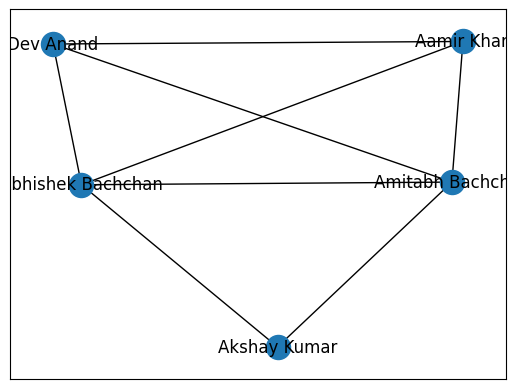

In [1]:
import networkx as nx
G_symmetric = nx.Graph()
G_symmetric.add_edge('Amitabh Bachchan','Abhishek Bachchan')
G_symmetric.add_edge('Amitabh Bachchan','Aamir Khan')
G_symmetric.add_edge('Amitabh Bachchan','Akshay Kumar')
G_symmetric.add_edge('Amitabh Bachchan','Dev Anand')
G_symmetric.add_edge('Abhishek Bachchan','Aamir Khan')
G_symmetric.add_edge('Abhishek Bachchan','Akshay Kumar')
G_symmetric.add_edge('Abhishek Bachchan','Dev Anand')
G_symmetric.add_edge('Dev Anand','Aamir Khan')
nx.draw_networkx(G_symmetric)
G_asymmetric = nx.DiGraph()
G_asymmetric.add_edge('A','B')
G_asymmetric.add_edge('A','D')
G_asymmetric.add_edge('C','A')
G_asymmetric.add_edge('D','E')
G_asymmetric.add_edge('A','E')

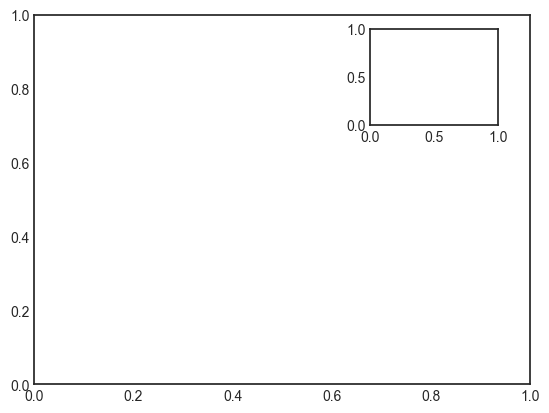

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-white')
fig = plt.figure()
ax1 = plt.axes()
ax2 = plt.axes([0.65, 0.65, 0.2, 0.2])
plt.show()

Undirected Graph
Menu
add vertex <key>
add edge <src> <dest> <weight>
mst
display
quit
[[153 126 161  54  73 154 162 113   8 198]
 [189 188  52  80  29 190 190  76  87  32]
 [146  80  89 126  16 108 100 195 134 189]
 [ 40  35  68  21 103 168 116 125 161 125]
 [  2 127  83 145 188 178  42 192  87 166]
 [ 46 146  96  10  35 128  25 168 147 156]
 [ 73 138 197  13 169 140 113 183  90 127]
 [ 14 114  96  37  20 103  62  46 151  76]
 [ 37 188 173 173  65  54 143  65 133  58]
 [176  37  29 146 113 144 103  80  28  38]]
Waktu Minimum Spanning Tree:0.000103
Total nilai sapnning= 340 dan jumlah edge= 9
Jalur terpendek dari node : 0 ke 9:  ['0', '8', '9']
weight dari  0  ke  8  =  8
weight dari  8  ke  9  =  58


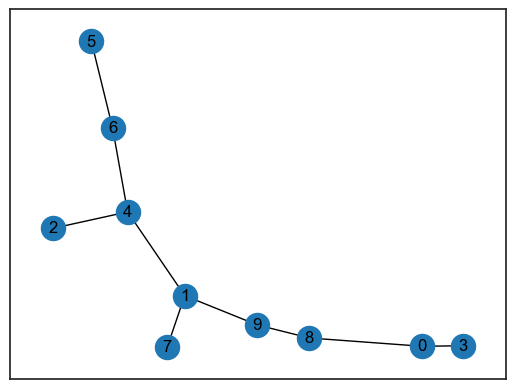

In [3]:
import networkx as nx
import numpy as np
import sys
import time

class Graph:
    def __init__(self):
        # dictionary containing keys that map to the corresponding vertex object
        self.vertices = {}

    def add_vertex(self, key):
        """Add a vertex with the given key to the graph."""
        vertex = Vertex(key)
        self.vertices[key] = vertex

    def get_vertex(self, key):
        """Return vertex object with the corresponding key."""
        return self.vertices[key]

    def __contains__(self, key):
        return key in self.vertices

    def add_edge(self, src_key, dest_key, weight=1):
        """Add edge from src_key to dest_key with given weight."""
        self.vertices[src_key].add_neighbour(self.vertices[dest_key], weight)

    def does_vertex_exist(self, key):
        return key in self.vertices

    def does_edge_exist(self, src_key, dest_key):
        """Return True if there is an edge from src_key to dest_key."""
        return self.vertices[src_key].does_it_point_to(self.vertices[dest_key])

    def display(self):
        #print('Vertices: ', end='')
        #for v in self:
        #    print(v.get_key(), end=' ')
        #print()
        list_edge = []

        #print('Edges: ')
        G_symmetric = nx.Graph()
        tot_w = 0
        tot_edge = 0
        for v in self:
            for dest in v.get_neighbours():
                w = v.get_weight(dest)
                if (int(v.get_key()) < int(dest.get_key())):
                    edge = []
                    tot_w += w
                    tot_edge += 1
                    edge.append(v.get_key())
                    edge.append(dest.get_key())
                    edge.append(w)
                    #print('(src={}, dest={}, weight={}) '.format(v.get_key(),
                    #                                         dest.get_key(), w))
                    list_edge.append(edge)
        print("Total nilai sapnning= %d dan jumlah edge= %d"%(tot_w,tot_edge))
        return list_edge

    def __len__(self):
        return len(self.vertices)

    def __iter__(self):
        return iter(self.vertices.values())


class Vertex:
    def __init__(self, key):
        self.key = key
        self.points_to = {}

    def get_key(self):
        """Return key corresponding to this vertex object."""
        return self.key

    def add_neighbour(self, dest, weight):
        """Make this vertex point to dest with given edge weight."""
        self.points_to[dest] = weight

    def get_neighbours(self):
        """Return all vertices pointed to by this vertex."""
        return self.points_to.keys()

    def get_weight(self, dest):
        """Get weight of edge from this vertex to dest."""
        return self.points_to[dest]

    def does_it_point_to(self, dest):
        """Return True if this vertex points to dest."""
        return dest in self.points_to


def mst_krusal(g):
    """Return a minimum cost spanning tree of the connected graph g."""
    mst = Graph() # create new Graph object to hold the MST

    if len(g) == 1:
        u = next(iter(g)) # get the single vertex
        mst.add_vertex(u.get_key()) # add a copy of it to mst
        return mst

    # get all the edges in a list
    edges = []
    for v in g:
        for n in v.get_neighbours():
            # avoid adding two edges for each edge of the undirected graph
            if v.get_key() < n.get_key():
                edges.append((v, n))

    # sort edges
    edges.sort(key=lambda edge: edge[0].get_weight(edge[1]))

    # initially, each vertex is in its own component
    component = {}
    for i, v in enumerate(g):
        component[v] = i

    # next edge to try
    edge_index = 0

    # loop until mst has the same number of vertices as g
    while len(mst) < len(g):
        u, v = edges[edge_index]
        edge_index += 1

        # if adding edge (u, v) will not form a cycle
        if component[u] != component[v]:

            # add to mst
            if not mst.does_vertex_exist(u.get_key()):
                mst.add_vertex(u.get_key())
            if not mst.does_vertex_exist(v.get_key()):
                mst.add_vertex(v.get_key())
            mst.add_edge(u.get_key(), v.get_key(), u.get_weight(v))
            mst.add_edge(v.get_key(), u.get_key(), u.get_weight(v))

            # merge components of u and v
            for w in g:
                if component[w] == component[v]:
                    component[w] = component[u]

    return mst


g = Graph()
print('Undirected Graph')
print('Menu')
print('add vertex <key>')
print('add edge <src> <dest> <weight>')
print('mst')
print('display')
print('quit')


N = 10

for i in range (0,N):
     g.add_vertex(str(i))

a = np.random.randint(2,200,(N,N), dtype=int)
print(a)

for i in range (0,N):
     for j in range (0,N):
         #if (i < j) :
            g.add_edge(str(i),str(j),a[i,j])

start = time.time()
mst = mst_krusal(g)
print('Waktu Minimum Spanning Tree:%2f'%(time.time()-start))
l_edge = mst.display()
G_sym = nx.Graph()
for e in l_edge:
    G_sym.add_edge(e[0],e[1],weight=int(e[2]))
nx.draw_networkx(G_sym)

sh_path = nx.shortest_path(G_sym,'0', str(N-1))
G_sp = nx.Graph()
print("Jalur terpendek dari node : 0 ke 9: ", sh_path)

for i in range (len(sh_path)-1):
    v1 = g.get_vertex((sh_path[i]))
    v2 = g.get_vertex((sh_path[i+1]))
    print("weight dari ",v1.get_key()," ke ",v2.get_key()," = ",v1.get_weight(v2))
    G_sp.add_edge(v1,v2,weight=v1.get_weight(v2))

# nx.draw_networkx(G_sp)


---


Copyright © Pengelola MK Praktikum Unggulan (Praktikum DGX), Universitas Gunadarma


https://www.praktikum-hpc.gunadarma.ac.id/